<a href="https://colab.research.google.com/github/mdanmek/nida-dads-notes/blob/main/dads5001-data-tools/project/eda/03_construction_eda_2569.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# การสำรวจโครงการจ้างก่อสร้าง ปีงบประมาณ 2569

ข้อมูล e-GP ปีงบประมาณ 2569 สะสมถึงวันที่ 30 กรกฎาคม 2569 ไม่ใช่ข้อมูลเต็มปี

In [130]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [131]:
from pathlib import Path
from matplotlib.patches import FancyBboxPatch

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)


In [132]:
base_dir = Path('/content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/dataset/procurement/egp-contract')

data_path = base_dir / 'processed' / 'construction_contracts_2569.csv'
project_output_path = base_dir / 'processed' / 'construction_projects_2569.csv'

project_dir = base_dir.parents[2]
figure_dir = project_dir / 'figure'
figure_dir.mkdir(parents=True, exist_ok=True)

print(f'Input file: {data_path}')
print(f'Project output: {project_output_path}')
print(f'Figure directory: {figure_dir}')

Input file: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/dataset/procurement/egp-contract/processed/construction_contracts_2569.csv
Project output: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/dataset/procurement/egp-contract/processed/construction_projects_2569.csv
Figure directory: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure


In [133]:
# ดาวน์โหลดฟอนต์สำหรับแสดงภาษาไทยในกราฟ
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf

fm.fontManager.addfont('thsarabunnew-webfont.ttf')

sns.set_theme(
    style='whitegrid',
    font='TH Sarabun New'
)

plt.rcParams.update({
    'axes.titlesize': 18,
    'axes.titleweight': 'semibold',
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.unicode_minus': False
})

BLUE = '#5B7FA3'
ORANGE = '#D9822B'
GRAY = '#B8C2CC'
TEXT = '#344054'
MUTED = '#667085'
GRID = '#E4E7EC'

## 1. สร้างข้อมูลระดับโครงการ

ข้อมูลหนึ่งโครงการอาจมีมากกว่าหนึ่งแถว จึงลดข้อมูลให้เหลือหนึ่งแถวต่อรหัสโครงการก่อนทำ EDA

In [134]:
construction_data = pd.read_csv(data_path, low_memory=False)

print(f'รายการจาก Notebook 02: {len(construction_data):,}')
print(f'จำนวนคอลัมน์: {construction_data.shape[1]:,}')

display(construction_data.head())

รายการจาก Notebook 02: 179,716
จำนวนคอลัมน์: 29


,ลำดับ,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,ชื่อประเภทโครงการ,ชื่อหน่วยงาน,ชื่อหน่วยงานย่อย,ชื่อวิธีการจัดซื้อจัดจ้าง,ชื่อกลุ่มวิธีการจัดซื้อจัดจ้าง,วันที่ประกาศจัดซื้อจัดจ้าง,วงเงินงบประมาณ (บาท),ราคากลาง (บาท),ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),ปีงบประมาณ,วันที่เกิดรายการ,จังหวัด,เขต/อำเภอ,แขวง/ตำบล,สถานะโครงการ,พิกัดของโครงการ,ละติจูดของโครงการ,ลองจิจูดของโครงการ,เลขประจำตัวนิติบุคคล 13 หลัก,ชื่อผู้ชนะการเสนอราคา,เลขที่สัญญา,วันที่ลงนามในสัญญา,วันที่สิ้นสุดสัญญา,วงเงินงบประมาณในสัญญา (บาท),สถานะสัญญา,source_file
0,2,67079254388,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างศูนย์การแ...,จ้างก่อสร้าง,กรุงเทพมหานคร,สำนักการโยธา กรุงเทพมหานคร,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,8 ก.ค. 68,"4,000,000,000.00","4,000,000,000.00","3,997,800,000.00",2569,7 ม.ค. 69,กรุงเทพมหานคร,ดินแดง,ดินแดง,ระหว่างดำเนินการ,POINT(100.51196175293 13.743704315315),13.74,100.51,0107537000939,บริษัท อิตาเลียนไทย ดีเวล๊อปเมนต์ จำกัด (มหาชน),กคส.สนย.๒๒-๕-๖๙,7 ม.ค. 69,26 พ.ค. 73,"3,997,800,000.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv
1,3,68049277788,ประกวดราคาจ้างก่อสร้างโครงการเปลี่ยนระบบสายไฟฟ...,จ้างก่อสร้าง,การไฟฟ้านครหลวง,ฝ่ายบริหารโครงการ การไฟฟ้านครหลวง,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,15 ก.ย. 68,"4,083,120,000.00","3,872,008,000.00","3,870,550,927.00",2569,29 เม.ย. 69,กรุงเทพมหานคร,คลองเตย,คลองเตย,ระหว่างดำเนินการ,"POLYGON((100.64566612244 13.762437066514,100.6...",13.79,100.69,0993000532988,กิจการร่วมค้า จีบีที,MP8-3404-ABL,29 เม.ย. 69,-,"3,870,550,927.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv
2,5,68109204474,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างสถาบันมะเ...,จ้างก่อสร้าง,สถาบันมะเร็งแห่งชาติ,สถาบันมะเร็งแห่งชาติ,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,6 ม.ค. 69,"3,300,000,000.00","3,407,005,257.46","3,285,000,000.00",2569,10 มิ.ย. 69,กรุงเทพมหานคร,ราชเทวี,ทุ่งพญาไท,ระหว่างดำเนินการ,"POLYGON((100.41905164719 13.570553229914,100.4...",13.57,100.42,0107547000273,บริษัท เอ็นแอล ดีเวลลอปเมนต์ จำกัด (มหาชน),192/2569 (พ),10 มิ.ย. 69,15 พ.ค. 74,"3,285,000,000.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv
3,6,68069459174,ประกวดราคาจ้างก่อสร้างโครงการเปลี่ยนระบบสายไฟฟ...,จ้างก่อสร้าง,การไฟฟ้านครหลวง,ฝ่ายบริหารโครงการ การไฟฟ้านครหลวง,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,28 พ.ย. 68,"3,370,500,000.00","3,285,232,000.00","3,282,800,000.00",2569,29 มิ.ย. 69,กรุงเทพมหานคร,คลองเตย,คลองเตย,ระหว่างดำเนินการ,"LINESTRING(100.62686920166 13.926236380743,100...",13.88,100.60,0993000536215,กิจการร่วมค้า เอสดับเบิ้ลยูซี,MP8-3402-ABL,29 มิ.ย. 69,10 ธ.ค. 72,"3,282,800,000.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv
4,7,67099642340,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างปรับปรุงข...,จ้างก่อสร้าง,การประปาส่วนภูมิภาค,กองจัดหา การประปาส่วนภูมิภาค,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,16 ก.ค. 68,"3,498,760,900.00","3,498,752,340.00","3,250,900,000.00",2569,20 พ.ย. 68,กรุงเทพมหานคร,หลักสี่,ตลาดบางเขน,ระหว่างดำเนินการ,POINT(98.5303660281 8.4326626992),8.43,98.53,0105519003571,บริษัท วงษ์สยามก่อสร้าง จำกัด,กจห.123/2568,20 พ.ย. 68,23 เม.ย. 71,"3,250,900,000.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv


In [135]:
project_id_column = 'รหัสโครงการ'
budget_column = 'วงเงินงบประมาณ (บาท)'
method_column = 'ชื่อวิธีการจัดซื้อจัดจ้าง'

project_columns = [
    project_id_column,
    'ชื่อโครงการจัดซื้อจัดจ้าง',
    'ชื่อประเภทโครงการ',
    'ชื่อหน่วยงาน',
    'ชื่อหน่วยงานย่อย',
    method_column,
    'ชื่อกลุ่มวิธีการจัดซื้อจัดจ้าง',
    'วันที่ประกาศจัดซื้อจัดจ้าง',
    budget_column,
    'ราคากลาง (บาท)',
    'ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท)',
    'ปีงบประมาณ',
    'วันที่เกิดรายการ',
    'จังหวัด',
    'เขต/อำเภอ',
    'แขวง/ตำบล',
    'สถานะโครงการ',
    'พิกัดของโครงการ',
    'ละติจูดของโครงการ',
    'ลองจิจูดของโครงการ'
]

In [136]:
project_data = construction_data[project_columns].drop_duplicates(subset=project_id_column,keep='first').copy()

project_data[budget_column] = pd.to_numeric(project_data[budget_column], errors='coerce')

print(f'รายการระดับสัญญา–บริษัท: {len(construction_data):,}')
print(f'โครงการไม่ซ้ำ: {len(project_data):,}')
print(f'แถวที่รวมเป็นระดับโครงการ: {len(construction_data) - len(project_data):,}')

รายการระดับสัญญา–บริษัท: 179,716
โครงการไม่ซ้ำ: 178,978
แถวที่รวมเป็นระดับโครงการ: 738


ข้อมูลสำหรับ EDA เหลือหนึ่งแถวต่อโครงการ

## 2. โครงการก่อสร้างส่วนใหญ่อยู่ช่วงใด

In [137]:
budget_summary = project_data[budget_column].describe(percentiles=[0.25, 0.50, 0.75, 0.95, 0.99])

display(budget_summary.to_frame(name='วงเงินงบประมาณ'))

print(f'Mean: {project_data[budget_column].mean():,.0f} บาท')
print(f'Median: {project_data[budget_column].median():,.0f} บาท')
print(f'99th percentile: {project_data[budget_column].quantile(0.99):,.0f} บาท')

,วงเงินงบประมาณ
count,"178,978.00"
mean,"2,659,155.23"
std,"30,273,037.92"
min,900.00
25%,"181,100.00"
50%,"395,000.00"
75%,"500,000.00"
95%,"9,751,915.00"
99%,"32,500,000.00"
max,"4,083,120,000.00"


Mean: 2,659,155 บาท
Median: 395,000 บาท
99th percentile: 32,500,000 บาท


In [138]:
common_budget_values = (
    project_data[budget_column]
    .value_counts()
    .head(15)
    .rename_axis('วงเงินงบประมาณ')
    .reset_index(name='จำนวนโครงการ')
)

common_budget_values['สัดส่วนโครงการ (%)'] = (common_budget_values['จำนวนโครงการ'] / len(project_data) * 100)

display(common_budget_values)

,วงเงินงบประมาณ,จำนวนโครงการ,สัดส่วนโครงการ (%)
0,"500,000.00",6523,3.64
1,"499,000.00",3593,2.01
2,"200,000.00",2527,1.41
3,"498,000.00",2438,1.36
4,"300,000.00",2266,1.27
5,"100,000.00",1991,1.11
6,"490,000.00",1790,1.00
7,"150,000.00",1527,0.85
8,"495,000.00",1525,0.85
9,"400,000.00",1481,0.83


In [139]:
budget_bins = [
    0,
    100_000,
    200_000,
    300_000,
    400_000,
    500_000,
    1_000_000,
    5_000_000,
    10_000_000,
    50_000_000,
    np.inf
]

budget_labels = [
    'ไม่เกิน 100,000',
    '100,001–200,000',
    '200,001–300,000',
    '300,001–400,000',
    '400,001–500,000',
    '500,001–1 ล้าน',
    'มากกว่า 1–5 ล้าน',
    'มากกว่า 5–10 ล้าน',
    'มากกว่า 10–50 ล้าน',
    'มากกว่า 50 ล้าน'
]

project_data['budget_band'] = pd.cut(
    project_data[budget_column],
    bins=budget_bins,
    labels=budget_labels,
    include_lowest=True
)

In [140]:
budget_band_summary = (
    project_data
    .groupby('budget_band', observed=False)
    .agg(
        project_count=(project_id_column, 'size'),
        total_budget=(budget_column, 'sum')
    )
    .reset_index()
)

budget_band_summary['project_pct'] = (
    budget_band_summary['project_count']
    / len(project_data)
    * 100
)

budget_band_summary['budget_pct'] = (
    budget_band_summary['total_budget']
    / budget_band_summary['total_budget'].sum()
    * 100
)

display(budget_band_summary)


,budget_band,project_count,total_budget,project_pct,budget_pct
0,"ไม่เกิน 100,000",23393,"1,391,944,502.51",13.07,0.29
1,"100,001–200,000",27835,"4,244,799,665.13",15.55,0.89
2,"200,001–300,000",22675,"5,754,249,900.83",12.67,1.21
3,"300,001–400,000",17815,"6,284,080,423.64",9.95,1.32
4,"400,001–500,000",44905,"21,508,548,791.78",25.09,4.52
5,"500,001–1 ล้าน",8171,"6,142,652,360.00",4.57,1.29
6,มากกว่า 1–5 ล้าน,18981,"49,057,947,604.33",10.61,10.31
7,มากกว่า 5–10 ล้าน,7899,"61,201,364,790.37",4.41,12.86
8,มากกว่า 10–50 ล้าน,6421,"138,630,828,482.95",3.59,29.13
9,มากกว่า 50 ล้าน,883,"181,713,868,683.13",0.49,38.18


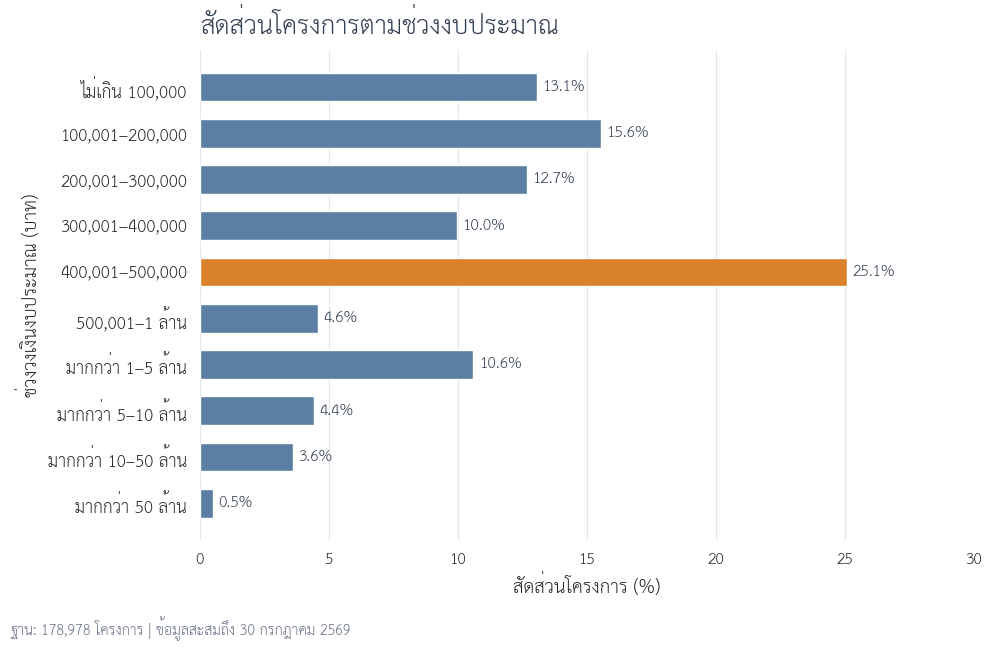

In [141]:
plot_data = budget_band_summary.copy()
colors = [
    ORANGE if str(band) == '400,001–500,000' else BLUE
    for band in plot_data['budget_band']
]

fig, ax = plt.subplots(figsize=(10, 6.5))

bars = ax.barh(
    plot_data['budget_band'],
    plot_data['project_pct'],
    color=colors,
    height=0.62
)

ax.bar_label(
    bars,
    labels=[f'{value:.1f}%' for value in plot_data['project_pct']],
    padding=4,
    fontsize=11,
    color=TEXT
)

ax.invert_yaxis()
ax.set_xlim(0, 30)
ax.set_title(
    'สัดส่วนโครงการตามช่วงงบประมาณ',
    loc='left',
    pad=12,
    color=TEXT
)
ax.set_xlabel('สัดส่วนโครงการ (%)')
ax.set_ylabel('ช่วงวงเงินงบประมาณ (บาท)')

ax.grid(axis='x', color=GRID, linewidth=0.8)
ax.grid(axis='y', visible=False)
ax.set_axisbelow(True)
sns.despine(left=True, bottom=True)

fig.text(
    0.01,
    0.01,
    f'ฐาน: {len(project_data):,} โครงการ | ข้อมูลสะสมถึง 30 กรกฎาคม 2569',
    fontsize=10,
    color=MUTED
)

fig.tight_layout(rect=[0, 0.04, 1, 1])

In [142]:
png_path = figure_dir / 'fig03_01_project_and_budget_share_by_budget_band.png'
svg_path = figure_dir / 'fig03_01_project_and_budget_share_by_budget_band.svg'

fig.savefig(png_path, dpi=180, bbox_inches='tight', facecolor='white')
fig.savefig(svg_path, bbox_inches='tight', facecolor='white')

print(f'Saved: {png_path}')
print(f'Saved: {svg_path}')

Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig03_01_project_and_budget_share_by_budget_band.png
Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig03_01_project_and_budget_share_by_budget_band.svg


### สิ่งที่พบ

วงเงินมัธยฐานอยู่ที่ 395,000 บาท ขณะที่ค่าเฉลี่ยประมาณ 2.66 ล้านบาท แสดงว่าข้อมูลเบ้ขวาจากโครงการขนาดใหญ่จำนวนน้อย

โครงการวงเงินไม่เกิน 500,000 บาทคิดเป็น 76.34% ของโครงการทั้งหมด โดยช่วง 400,001–500,000 บาทมีสัดส่วนสูงที่สุดที่ 25.1%

## 3. การกระจายของโครงการรอบ 500,000 บาท

แสดงจำนวนโครงการในช่วง 400,000–550,000 บาท โดยแบ่งช่วงละประมาณ 10,000 บาท

In [143]:
threshold_bands = [
    (400_000, 409_999, '400–409k'),
    (410_000, 419_999, '410–419k'),
    (420_000, 429_999, '420–429k'),
    (430_000, 439_999, '430–439k'),
    (440_000, 449_999, '440–449k'),
    (450_000, 459_999, '450–459k'),
    (460_000, 469_999, '460–469k'),
    (470_000, 479_999, '470–479k'),
    (480_000, 489_999, '480–489k'),
    (490_000, 500_000, '490–500k'),
    (500_001, 510_000, '500–510k'),
    (510_001, 520_000, '510–520k'),
    (520_001, 530_000, '520–530k'),
    (530_001, 540_000, '530–540k'),
    (540_001, 550_000, '540–550k')
]

threshold_results = []

for lower, upper, label in threshold_bands:
    project_count = project_data[budget_column].between(
        lower,
        upper,
        inclusive='both'
    ).sum()

    threshold_results.append({
        'ช่วงวงเงิน': label,
        'จำนวนโครงการ': project_count,
        'ต่ำกว่า/เท่ากับเพดาน': upper <= 500_000
    })

threshold_summary = pd.DataFrame(threshold_results)

display(threshold_summary)


,ช่วงวงเงิน,จำนวนโครงการ,ต่ำกว่า/เท่ากับเพดาน
0,400–409k,2864,True
1,410–419k,1386,True
2,420–429k,1775,True
3,430–439k,1393,True
4,440–449k,1612,True
5,450–459k,2251,True
6,460–469k,1872,True
7,470–479k,2416,True
8,480–489k,4576,True
9,490–500k,26240,True


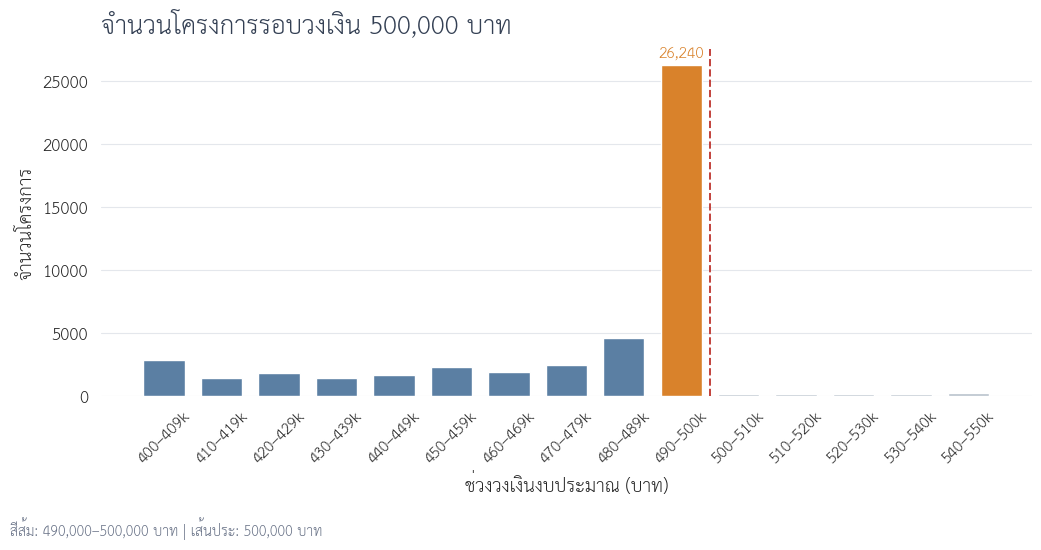

In [144]:
colors = [
    ORANGE if index == 9 else BLUE if index < 9 else GRAY
    for index in threshold_summary.index
]

fig, ax = plt.subplots(figsize=(10.5, 5.5))

bars = ax.bar(
    threshold_summary['ช่วงวงเงิน'],
    threshold_summary['จำนวนโครงการ'],
    color=colors,
    width=0.72
)

peak_index = threshold_summary['จำนวนโครงการ'].idxmax()
peak_value = threshold_summary.loc[peak_index, 'จำนวนโครงการ']

ax.text(
    peak_index,
    peak_value + 700,
    f'{peak_value:,.0f}',
    ha='center',
    fontsize=11,
    fontweight='semibold',
    color=ORANGE
)

ax.axvline(
    9.5,
    color='#C2413B',
    linestyle='--',
    linewidth=1.4
)

ax.set_title(
    'จำนวนโครงการรอบวงเงิน 500,000 บาท',
    loc='left',
    pad=12,
    color=TEXT
)
ax.set_xlabel('ช่วงวงเงินงบประมาณ (บาท)')
ax.set_ylabel('จำนวนโครงการ')
ax.tick_params(axis='x', rotation=45)

ax.grid(axis='y', color=GRID, linewidth=0.8)
ax.grid(axis='x', visible=False)
ax.set_axisbelow(True)
sns.despine(left=True, bottom=True)

fig.text(
    0.01,
    0.01,
    'สีส้ม: 490,000–500,000 บาท | เส้นประ: 500,000 บาท',
    fontsize=10,
    color=MUTED
)

fig.tight_layout(rect=[0, 0.05, 1, 1])

In [145]:
png_path = figure_dir / 'fig03_02_budget_distribution_around_500k.png'
svg_path = figure_dir / 'fig03_02_budget_distribution_around_500k.svg'

fig.savefig(png_path, dpi=180, bbox_inches='tight', facecolor='white')
fig.savefig(svg_path, bbox_inches='tight', facecolor='white')

print(f'Saved: {png_path}')
print(f'Saved: {svg_path}')

Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig03_02_budget_distribution_around_500k.png
Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig03_02_budget_distribution_around_500k.svg


### สิ่งที่พบ

ช่วง 490,000–500,000 บาทมี 26,240 โครงการ สูงกว่าช่วงใกล้เคียงอย่างชัดเจน

การกระจุกใกล้ 500,000 บาทยังไม่ใช่หลักฐานว่าโครงการผิดปกติ

## 4. วิธีจัดซื้อของโครงการใกล้ 500,000 บาท

วิเคราะห์วิธีจัดซื้อเฉพาะโครงการที่มีวงเงิน 490,000–500,000 บาท

In [146]:
near_ceiling_data = project_data[
    project_data[budget_column].between(
        490_000,
        500_000,
        inclusive='both'
    )
].copy()

method_summary = (
    near_ceiling_data
    .groupby(method_column)
    .agg(
        project_count=(project_id_column, 'size'),
        total_budget=(budget_column, 'sum')
    )
    .reset_index()
)

method_summary['project_pct'] = (
    method_summary['project_count']
    / len(near_ceiling_data)
    * 100
)

method_summary = method_summary.sort_values(
    'project_count',
    ascending=False
).reset_index(drop=True)

display(method_summary)

dominant_method = method_summary.iloc[0]

print(
    f"วิธีที่พบมากที่สุด: {dominant_method[method_column]} "
    f"{dominant_method['project_count']:,.0f} โครงการ "
    f"({dominant_method['project_pct']:.1f}%)"
)

,ชื่อวิธีการจัดซื้อจัดจ้าง,project_count,total_budget,project_pct
0,เฉพาะเจาะจง,26154,"13,001,722,833.43",99.67
1,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),81,"40,350,012.68",0.31
2,คัดเลือก,5,"2,488,200.00",0.02


วิธีที่พบมากที่สุด: เฉพาะเจาะจง 26,154 โครงการ (99.7%)


In [147]:
method_names = {
    'เฉพาะเจาะจง': 'เฉพาะเจาะจง',
    'ประกวดราคาอิเล็กทรอนิกส์ (e-bidding)': 'e-bidding',
    'คัดเลือก': 'คัดเลือก',
    'ตกลงราคา': 'ตกลงราคา'
}

method_plot = method_summary.copy()

method_plot['method_label'] = (
    method_plot[method_column]
    .map(method_names)
    .fillna(method_plot[method_column])
)

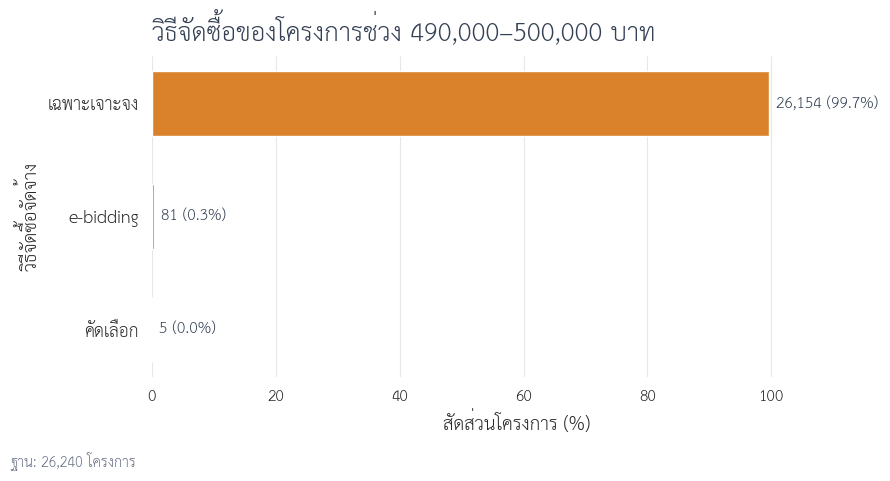

In [148]:
method_plot = method_plot.sort_values(
    'project_count',
    ascending=True
).reset_index(drop=True)

colors = [
    ORANGE if method == 'เฉพาะเจาะจง' else BLUE
    for method in method_plot['method_label']
]

fig, ax = plt.subplots(figsize=(9, 4.8))

bars = ax.barh(
    method_plot['method_label'],
    method_plot['project_pct'],
    color=colors,
    height=0.58
)

ax.bar_label(
    bars,
    labels=[
        f"{count:,.0f} ({pct:.1f}%)"
        for count, pct in zip(
            method_plot['project_count'],
            method_plot['project_pct']
        )
    ],
    padding=5,
    fontsize=11,
    color=TEXT
)

ax.set_xlim(0, max(method_plot['project_pct'].max() * 1.18, 10))
ax.set_title(
    'วิธีจัดซื้อของโครงการช่วง 490,000–500,000 บาท',
    loc='left',
    pad=12,
    color=TEXT
)
ax.set_xlabel('สัดส่วนโครงการ (%)')
ax.set_ylabel('วิธีจัดซื้อจัดจ้าง')

ax.grid(axis='x', color=GRID, linewidth=0.8)
ax.grid(axis='y', visible=False)
ax.set_axisbelow(True)
sns.despine(left=True, bottom=True)

fig.text(
    0.01,
    0.01,
    f'ฐาน: {len(near_ceiling_data):,} โครงการ',
    fontsize=10,
    color=MUTED
)

fig.tight_layout(rect=[0, 0.04, 1, 1])

In [149]:
png_path = figure_dir / 'fig03_03_method_share_near_500k.png'
svg_path = figure_dir / 'fig03_03_method_share_near_500k.svg'

fig.savefig(png_path, dpi=180, bbox_inches='tight', facecolor='white')
fig.savefig(svg_path, bbox_inches='tight', facecolor='white')

print(f'Saved: {png_path}')
print(f'Saved: {svg_path}')

Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig03_03_method_share_near_500k.png
Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig03_03_method_share_near_500k.svg


### สิ่งที่พบ

จาก 26,240 โครงการในช่วง 490,000–500,000 บาท เป็นวิธีเฉพาะเจาะจง 26,154 โครงการ หรือ 99.7%

## 5. ข้อกำหนดเกี่ยวกับวงเงิน 500,000 บาท

- พระราชบัญญัติการจัดซื้อจัดจ้างฯ พ.ศ. 2560 มาตรา 55 กำหนดวิธีจัดซื้อจัดจ้างพัสดุ 3 วิธี ได้แก่ วิธีประกาศเชิญชวนทั่วไป วิธีคัดเลือก และวิธีเฉพาะเจาะจง
- มาตรา 56 วรรคหนึ่ง (2)(ข) อนุญาตให้ใช้วิธีเฉพาะเจาะจงเมื่อวงเงินต่อครั้งไม่เกินวงเงินที่กำหนดในกฎกระทรวง
- กฎกระทรวงกำหนดวงเงินดังกล่าวไว้ไม่เกิน 500,000 บาท

แหล่งอ้างอิง: [พระราชบัญญัติการจัดซื้อจัดจ้างฯ ในราชกิจจานุเบกษา](https://www.ratchakitcha.soc.go.th/) และ [กฎหมาย/ระเบียบด้านการจัดซื้อจัดจ้างของกรมบัญชีกลาง](https://www.cgd.go.th/)

การกระจุกของโครงการวิธีเฉพาะเจาะจงใต้ 500,000 บาทจึงสอดคล้องกับเงื่อนไขตามกฎหมาย และไม่ถือเป็นความผิดปกติด้วยตัวเอง

## 6. โครงการที่เข้าเงื่อนไข

เลือกโครงการวิธีเฉพาะเจาะจงที่มีวงเงินไม่เกิน 500,000 บาท

In [150]:
under_500k_mask = project_data[budget_column] <= 500_000

study_population_mask = (under_500k_mask & project_data[method_column].eq('เฉพาะเจาะจง'))

project_data['is_study_population'] = study_population_mask
study_project_data = project_data[study_population_mask].copy()

study_scope = pd.DataFrame({
    'ขั้นการเลือกข้อมูล': [
        'โครงการก่อสร้างทั้งหมด',
        'วงเงินไม่เกิน 500,000 บาท',
        'เฉพาะเจาะจงและไม่เกิน 500,000 บาท'
    ],
    'project_count': [
        len(project_data),
        under_500k_mask.sum(),
        len(study_project_data)
    ]
})

study_scope['project_pct'] = (study_scope['project_count'] / len(project_data) * 100)

display(study_scope)

,ขั้นการเลือกข้อมูล,project_count,project_pct
0,โครงการก่อสร้างทั้งหมด,178978,100.00
1,"วงเงินไม่เกิน 500,000 บาท",136623,76.34
2,"เฉพาะเจาะจงและไม่เกิน 500,000 บาท",136070,76.03


### ผลการคัดเลือก

จากโครงการก่อสร้าง 178,978 โครงการ มี 136,623 โครงการที่วงเงินไม่เกิน 500,000 บาท และ 136,070 โครงการเป็นวิธีเฉพาะเจาะจง

โครงการ 136,070 รายการเป็นกลุ่มที่เข้าเงื่อนไข ไม่ได้หมายความว่าเป็นโครงการผิดปกติ

In [151]:
project_data.to_csv(
    project_output_path,
    index=False,
    encoding='utf-8-sig'
)

print(f'Project rows saved: {len(project_data):,}')
print(f'Study population: {len(study_project_data):,}')
print(f'Saved to: {project_output_path}')


Project rows saved: 178,978
Study population: 136,070
Saved to: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/dataset/procurement/egp-contract/processed/construction_projects_2569.csv


## 7. สรุป

- โครงการก่อสร้างมีวงเงินมัธยฐาน 395,000 บาท
- ช่วง 400,001–500,000 บาทมีสัดส่วนโครงการสูงที่สุด
- ช่วง 490,000–500,000 บาทมี 26,240 โครงการ
- ในจำนวนนี้ 26,154 โครงการ หรือ 99.7% ใช้วิธีเฉพาะเจาะจง
- การกระจุกใต้ 500,000 บาทสอดคล้องกับเงื่อนไขการใช้วิธีเฉพาะเจาะจงตามกฎหมาย
- โครงการวิธีเฉพาะเจาะจงและวงเงินไม่เกิน 500,000 บาทมี 136,070 โครงการ